In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
df =  pd.read_csv("blinkit_data.csv")

In [73]:
df.head(5)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [74]:
df.tail(5)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8518,low fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,reg,FDM58,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


In [76]:
df.shape

(8523, 12)

In [75]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

In [8]:
df.dtypes

,0
Item Fat Content,object
Item Identifier,object
Item Type,object
Outlet Establishment Year,int64
Outlet Identifier,object
Outlet Location Type,object
Outlet Size,object
Outlet Type,object
Item Visibility,float64
Item Weight,float64


In [81]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat']


In [80]:
df['Item Fat Content'] = df['Item Fat Content'].replace({'low fat':'Low Fat', 'LF':'Low Fat','reg':'Regular'})

In [82]:
total_sales = df['Sales'].sum()
average_sales = df['Sales'].mean()
no_of_item_sold = df['Sales'].count()
avg_rating = df['Rating'].mean()

print(f"Total Sales: ${total_sales:,.0f}")
print(f"Average Sales: ${average_sales:,.0f}")
print(f"No of Items sold: {no_of_item_sold:,.0f}")
print(f"Average Ratings: {avg_rating:,.1f}")

Total Sales: $1,201,681
Average Sales: $141
No of Items sold: 8,523
Average Ratings: 4.0


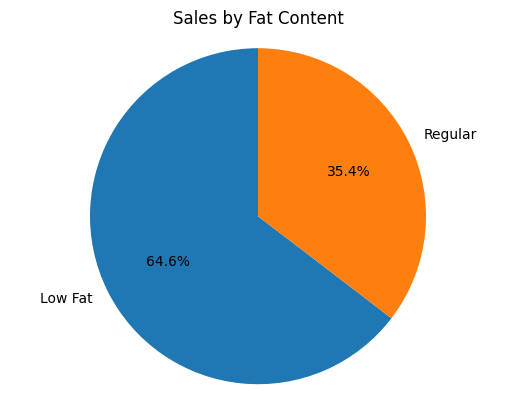

In [83]:
sales_by_fat =  df.groupby('Item Fat Content')['Sales'].sum()

plt.pie(sales_by_fat,labels=sales_by_fat.index,autopct='%.1f%%',startangle=90)
plt.title('Sales by Fat Content')
plt.axis('equal')
plt.show()


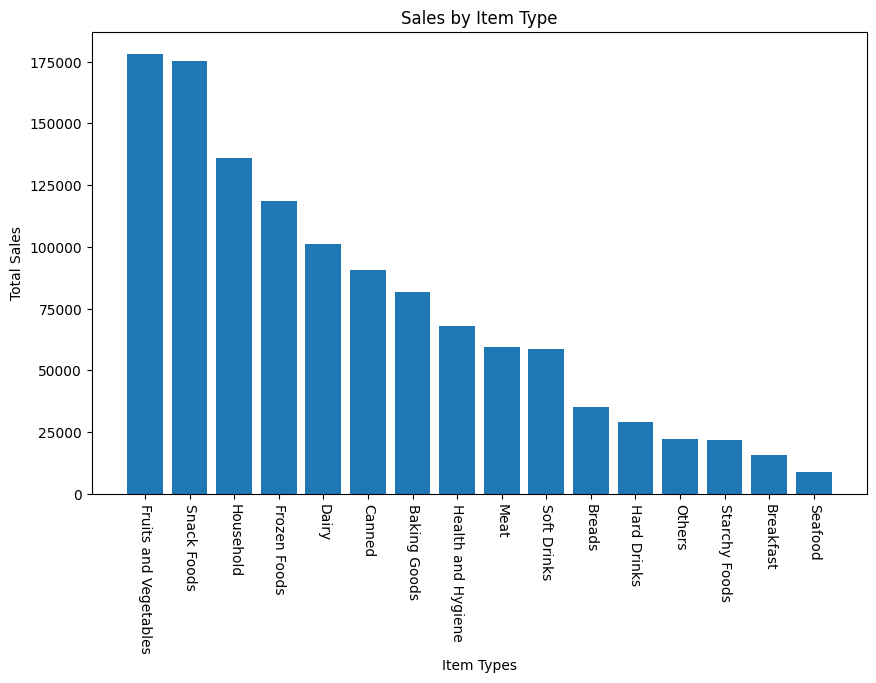

In [84]:
sales_by_type = df.groupby('Item Type')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
bars = plt.bar(sales_by_type.index, sales_by_type.values)

plt.xticks(rotation=-90)

plt.title('Sales by Item Type')
plt.xlabel('Item Types')
plt.ylabel('Total Sales')

plt.show()

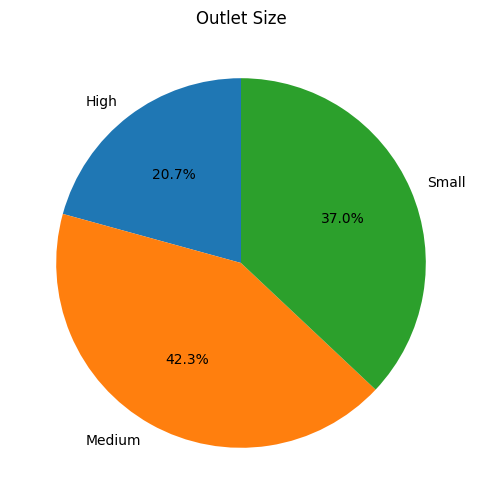

In [85]:
sales_by_size = df.groupby('Outlet Size')['Sales'].sum()

plt.figure(figsize=(6,6))
plt.pie(sales_by_size,labels= sales_by_size.index, autopct= '%1.1f%%', startangle=90)
plt.title('Outlet Size')
plt.show()

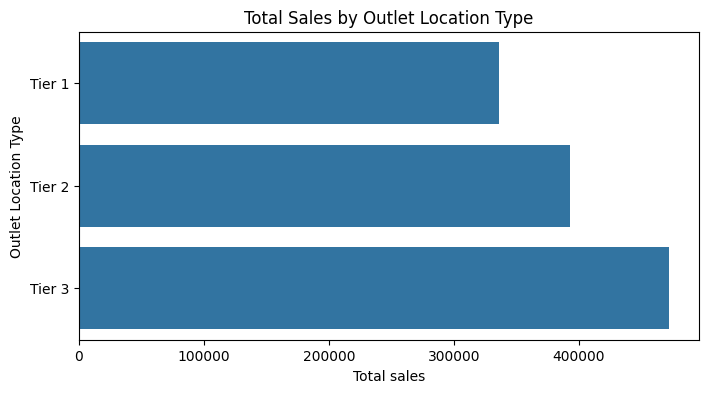

In [86]:
sales_by_location = df.groupby('Outlet Location Type')['Sales'].sum().reset_index()

plt.figure(figsize=(8,4))
ax = sns.barplot(x='Sales', y='Outlet Location Type', data = sales_by_location)

plt.title('Total Sales by Outlet Location Type')
plt.xlabel('Total sales')
plt.ylabel('Outlet Location Type')
plt.show()


